In [8]:
!pip install lightgbm

In [9]:
import pandas as pd

# Load the Excel file into df_raw
df_raw = pd.read_excel('/content/Navi Mumbai 6 CAAQMS daily data.xlsx')

# Display the first few rows and information to confirm it's loaded correctly
print('df_raw loaded successfully:')
display(df_raw.head())
df_raw.info()

df_raw loaded successfully:


,Date,Month,Day,Year,Location,Regional Office,PM10,PM25,SO2,NO2,...,NOx,NO,OXYLENE,RG,SR,TEMP,TOLU,WD,WS,AQI
0,2022-11-28,11,28.0,2022,Belapur,Navi Mumbai,96.25,43.08,6.56,60.80,...,60.80,11.56,3.64,0.0,110.3,29.02,51.39,265.46,0.38,96.25
1,2022-11-29,11,29.0,2022,Belapur,Navi Mumbai,150.99,64.11,15.85,101.57,...,101.57,36.60,6.28,0.0,102.9,27.71,34.65,268.79,0.37,133.993333
2,2022-11-30,11,30.0,2022,Belapur,Navi Mumbai,188.77,90.66,11.91,86.60,...,86.60,32.22,7.05,0.0,92.9,29.06,35.27,263.84,0.31,202.2
3,2022-12-01,12,1.0,2022,Belapur,Navi Mumbai,169.99,87.43,13.69,65.93,...,65.93,32.63,5.59,0.4,99.7,28.54,27.57,262.29,0.31,191.433333
4,2022-12-02,12,2.0,2022,Belapur,Navi Mumbai,191.14,94.34,14.78,80.26,...,80.26,37.77,5.58,0.0,103.8,27.91,30.25,264.85,0.33,214.466667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3931 entries, 0 to 3930
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             3931 non-null   datetime64[ns]
 1   Month            3931 non-null   int64         
 2   Day              3931 non-null   float64       
 3   Year             3931 non-null   int64         
 4   Location         3931 non-null   object        
 5   Regional Office  3931 non-null   object        
 6   PM10             3854 non-null   float64       
 7   PM25             3843 non-null   float64       
 8   SO2              3844 non-null   float64       
 9   NO2              3850 non-null   float64       
 10  CO               3780 non-null   object        
 11  O3               3845 non-null   float64       
 12  NH3              3783 non-null   float64       
 13  BENZ             3845 non-null   float64       
 14  ETHBENZ          3843 non-null   float64

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# --- Helper Functions (Identical to before) ---

def compute_metrics(y_true, y_pred):
    """Calculates regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

def run_and_record(model, name, results_list):
    """Trains, evaluates, and records metrics for a given model."""
    print(f"Running: {name}...")
    t0 = time.time()
    # Fit LightGBM model
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="No further splits with positive gain, best gain: -inf")
        model.fit(X_train_scaled, y_train_scaled.ravel())
    train_time = time.time() - t0

    pred_scaled = model.predict(X_test_scaled)
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

    # Calculate metrics
    metrics = compute_metrics(y_test, pred)

    result_data = {
        "name": name,
        "model": model,
        "metrics": metrics,
        "train_time": train_time
    }
    results_list.append(result_data)
    return result_data

# List to collect all results
all_results = []

# --- Data cleaning with MICE imputer (Identical to before) ---

try:
    df = df_raw.copy()
    print("Using df_raw from environment for preprocessing.")
except NameError:
    raise RuntimeError("df_raw not found. Please run the first cell to load the data.")

TARGET_COLUMN = 'AQI'
print(f"Using target column: {TARGET_COLUMN}")

X = df.drop(columns=[TARGET_COLUMN])
X['CO'] = pd.to_numeric(X['CO'], errors='coerce')
y = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').values.reshape(-1, 1)

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Numeric cols: {len(numeric_cols)}, Categorical cols: {len(cat_cols)}")

print("Starting MICE imputation for numeric features...")
num_imputer = IterativeImputer(random_state=0, max_iter=10)
X_num = pd.DataFrame(num_imputer.fit_transform(X[numeric_cols]), columns=numeric_cols, index=X.index)

if len(cat_cols) > 0:
    print("Imputing and One-Hot Encoding categorical features...")
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols, index=X.index)
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_ohe = pd.DataFrame(ohe.fit_transform(X_cat),
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X.index)
    X_proc = pd.concat([X_num, X_cat_ohe], axis=1)
else:
    X_proc = X_num

if np.any(pd.isna(y)):
    print('Imputing missing values in target with IterativeImputer...')
    target_imputer = IterativeImputer(random_state=0, max_iter=10)
    y = target_imputer.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)

print("Scaling data...")
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

print('--- Preprocessing Complete ---')
print('Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y')


Using df_raw from environment for preprocessing.
Using target column: AQI
Numeric cols: 23, Categorical cols: 2
Starting MICE imputation for numeric features...
Imputing and One-Hot Encoding categorical features...
Imputing missing values in target with IterativeImputer...
Scaling data...
--- Preprocessing Complete ---
Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y


In [11]:
# Model 6: LightGBM Base
lgb_base = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

res_base = run_and_record(lgb_base, "LGBM_base", all_results)

# Show base metrics
print(f"Base Model Training Time: {res_base['train_time']:.2f}s")
display(pd.DataFrame([{"variant": res_base['name'], **res_base['metrics']}]))

Running: LGBM_base...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

,variant,rmse,mae,r2
0,LGBM_base,6.050136,3.382562,0.99244


In [12]:
# Model 6: LightGBM Base
lgb_base = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

res_base = run_and_record(lgb_base, "LGBM_base", all_results)

# Show base metrics
print(f"Base Model Training Time: {res_base['train_time']:.2f}s")
display(pd.DataFrame([{"variant": res_base['name'], **res_base['metrics']}]))

Running: LGBM_base...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,variant,rmse,mae,r2
0,LGBM_base,6.050136,3.382562,0.99244


Running: LGBM_n_estimators_100...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

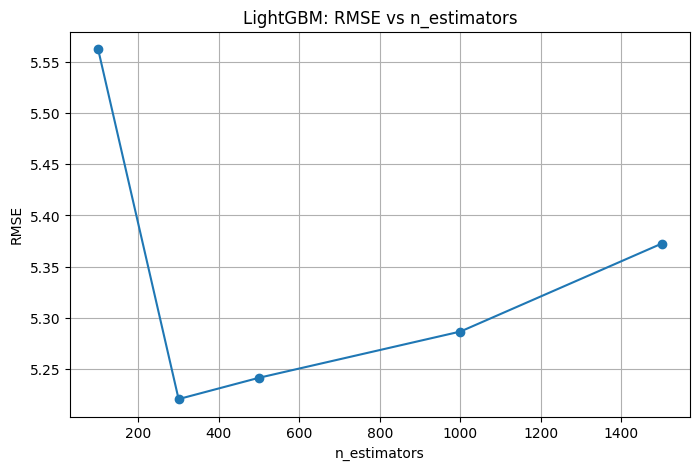

,rmse,mae,r2
n_estimators,,,
100,5.562430,2.607673,0.993610
300,5.220643,2.619839,0.994371
500,5.241481,2.680818,0.994326
1000,5.286599,2.782179,0.994228
1500,5.372477,2.859238,0.994039


In [13]:
n_estimators_list = [100, 300, 500, 1000, 1500]
results_n = []

for n in n_estimators_list:
    model = LGBMRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )
    r = run_and_record(model, f"LGBM_n_estimators_{n}", all_results)
    results_n.append(r)

# Build DataFrame for plotting
df_n = pd.DataFrame([{
    "n_estimators": r['model'].get_params()['n_estimators'],
    **r['metrics']
} for r in results_n])

plt.figure(figsize=(8,5))
plt.plot(df_n['n_estimators'], df_n['rmse'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('LightGBM: RMSE vs n_estimators')
plt.grid(True)
plt.savefig('lgbm_n_estimators_sweep.png')
plt.show()

# Show table
display(df_n.set_index('n_estimators'))

Running: LGBM_lr_0.01...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

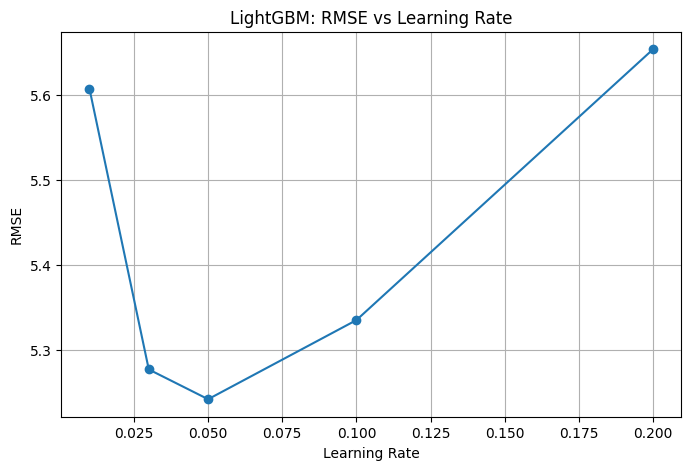

,rmse,mae,r2
learning_rate,,,
0.01,5.607446,2.644871,0.993506
0.03,5.276572,2.624366,0.994250
0.05,5.241481,2.680818,0.994326
0.10,5.334740,2.843382,0.994122
0.20,5.653972,3.134967,0.993398


In [14]:
learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.2]
results_lr = []

for lr in learning_rate_list:
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=lr,
        max_depth=10,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )
    r = run_and_record(model, f"LGBM_lr_{lr}", all_results)
    results_lr.append(r)

# Build DataFrame for plotting
df_lr = pd.DataFrame([{
    "learning_rate": r['model'].get_params()['learning_rate'],
    **r['metrics']
} for r in results_lr])

plt.figure(figsize=(8,5))
plt.plot(df_lr['learning_rate'], df_lr['rmse'], marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('LightGBM: RMSE vs Learning Rate')
plt.grid(True)
plt.savefig('lgbm_learning_rate_sweep.png')
plt.show()

# Show table
display(df_lr.set_index('learning_rate'))

Running: LGBM_depth_6_leaves_32...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

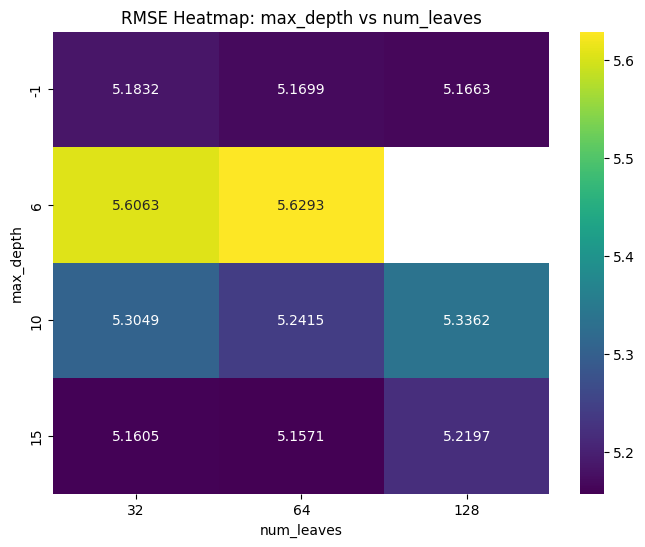

num_leaves,32,64,128
max_depth,,,
-1,5.183152,5.169901,5.166300
6,5.606255,5.629290,NaN
10,5.304892,5.241481,5.336210
15,5.160495,5.157128,5.219703


In [15]:
depth_list = [6, 10, 15, -1] # -1 = no limit
num_leaves_list = [32, 64, 128]
results_leaves = []

for d in depth_list:
    for nl in num_leaves_list:
        # num_leaves must be <= 2^max_depth (or it's redundant)
        if d != -1 and nl > (2**d):
            continue

        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=d,
            num_leaves=nl,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_depth_{d}_leaves_{nl}"
        r = run_and_record(model, name, all_results)
        results_leaves.append(r)

# Pivot table for RMSE
rows = []
for r in results_leaves:
    params = r['model'].get_params()
    rows.append({
        'max_depth': params['max_depth'],
        'num_leaves': params['num_leaves'],
        'rmse': r['metrics']['rmse']
    })

df_leaves = pd.DataFrame(rows)
pivot_leaves = df_leaves.pivot(index='max_depth', columns='num_leaves', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_leaves, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('num_leaves')
plt.ylabel('max_depth')
plt.title('RMSE Heatmap: max_depth vs num_leaves')
plt.savefig('lgbm_depth_leaves_heatmap.png')
plt.show()

display(pivot_leaves)

Running: LGBM_sub_0.7_col_0.7...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

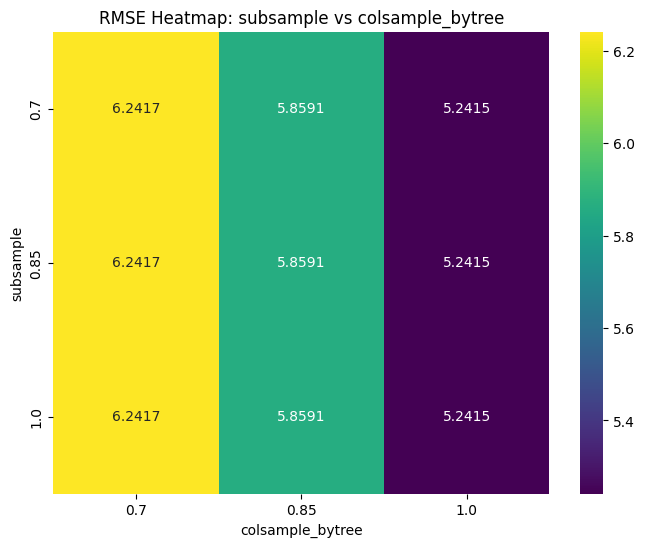

colsample_bytree,0.70,0.85,1.00
subsample,,,
0.70,6.24174,5.859092,5.241481
0.85,6.24174,5.859092,5.241481
1.00,6.24174,5.859092,5.241481


In [16]:
subsample_list = [0.7, 0.85, 1.0] # 1.0 = use all data
colsample_list = [0.7, 0.85, 1.0] # 1.0 = use all features
results_sub = []

for ss in subsample_list:
    for cs in colsample_list:
        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            num_leaves=64,
            subsample=ss,
            colsample_bytree=cs,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_sub_{ss}_col_{cs}"
        r = run_and_record(model, name, all_results)
        results_sub.append(r)

# Pivot table for RMSE
rows = []
for r in results_sub:
    params = r['model'].get_params()
    rows.append({
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'rmse': r['metrics']['rmse']
    })

df_sub = pd.DataFrame(rows)
pivot_sub = df_sub.pivot(index='subsample', columns='colsample_bytree', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('colsample_bytree')
plt.ylabel('subsample')
plt.title('RMSE Heatmap: subsample vs colsample_bytree')
plt.savefig('lgbm_subsample_heatmap.png')
plt.show()

display(pivot_sub)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

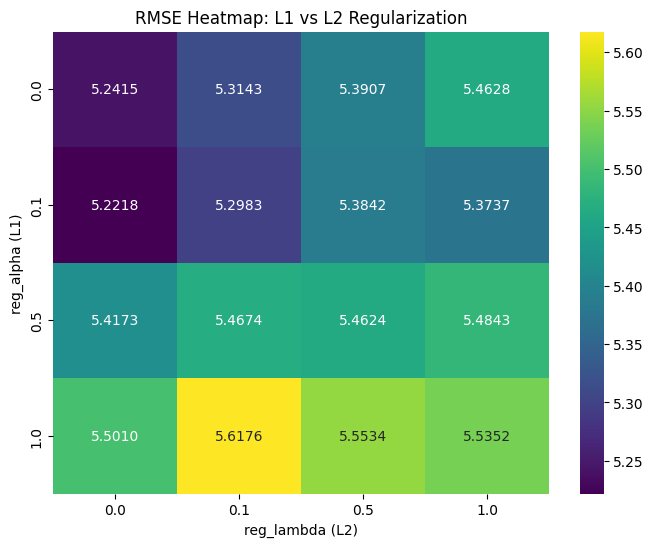

reg_lambda (L2),0.0,0.1,0.5,1.0
reg_alpha (L1),,,,
0.0,5.241481,5.314289,5.390746,5.462834
0.1,5.221844,5.298260,5.384209,5.373678
0.5,5.417277,5.467436,5.462450,5.484317
1.0,5.500968,5.617620,5.553370,5.535233


In [17]:
alpha_list = [0.0, 0.1, 0.5, 1.0]
lambda_list = [0.0, 0.1, 0.5, 1.0]
results_reg = []

for ra in alpha_list:
    for rl in lambda_list:
        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            num_leaves=64,
            reg_alpha=ra,
            reg_lambda=rl,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_alpha_{ra}_lambda_{rl}"
        r = run_and_record(model, name, all_results)
        results_reg.append(r)

# Pivot table for RMSE
rows = []
for r in results_reg:
    params = r['model'].get_params()
    rows.append({
        'reg_alpha (L1)': params['reg_alpha'],
        'reg_lambda (L2)': params['reg_lambda'],
        'rmse': r['metrics']['rmse']
    })

df_reg = pd.DataFrame(rows)
pivot_reg = df_reg.pivot(index='reg_alpha (L1)', columns='reg_lambda (L2)', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_reg, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('reg_lambda (L2)')
plt.ylabel('reg_alpha (L1)')
plt.title('RMSE Heatmap: L1 vs L2 Regularization')
plt.savefig('lgbm_regularization_heatmap.png')
plt.show()

display(pivot_reg)

In [18]:
summary_rows = []
for r in all_results:
    params = r['model'].get_params()
    summary_rows.append({
        'name': r['name'],
        'n_estimators': params.get('n_estimators'),
        'depth': params.get('max_depth'),
        'learning_rate': params.get('learning_rate'),
        'num_leaves': params.get('num_leaves'),
        'subsample': params.get('subsample'),
        'colsample_bytree': params.get('colsample_bytree'),
        'reg_alpha': params.get('reg_alpha'),
        'reg_lambda': params.get('reg_lambda'),
        'rmse': r['metrics']['rmse'],
        'mae': r['metrics']['mae'],
        'r2': r['metrics']['r2'],
        'train_time_s': r['train_time']
    })

df_summary = pd.DataFrame(summary_rows).sort_values('rmse')

# Show top 10 best runs
print("Top 10 performing LightGBM models by RMSE:")
display(df_summary.head(10))

# Save summary to CSV
try:
    df_summary.to_csv('lightgbm_parameter_sweep_summary.csv', index=False)
    print('\nSaved summary to lightgbm_parameter_sweep_summary.csv')
except Exception as e:
    print(f'Could not save summary CSV: {e}')

Top 10 performing LightGBM models by RMSE:


,name,n_estimators,depth,learning_rate,num_leaves,subsample,colsample_bytree,reg_alpha,reg_lambda,rmse,mae,r2,train_time_s
18,LGBM_depth_15_leaves_64,500,15,0.05,64,1.00,1.0,0.0,0.0,5.157128,2.689301,0.994507,1.035959
17,LGBM_depth_15_leaves_32,500,15,0.05,32,1.00,1.0,0.0,0.0,5.160495,2.648213,0.994500,0.786112
22,LGBM_depth_-1_leaves_128,500,-1,0.05,128,1.00,1.0,0.0,0.0,5.166300,2.633380,0.994487,3.950240
21,LGBM_depth_-1_leaves_64,500,-1,0.05,64,1.00,1.0,0.0,0.0,5.169901,2.656721,0.994480,1.603788
20,LGBM_depth_-1_leaves_32,500,-1,0.05,32,1.00,1.0,0.0,0.0,5.183152,2.673516,0.994451,0.855749
19,LGBM_depth_15_leaves_128,500,15,0.05,128,1.00,1.0,0.0,0.0,5.219703,2.644359,0.994373,1.281755
3,LGBM_n_estimators_300,300,10,0.05,64,1.00,1.0,0.0,0.0,5.220643,2.619839,0.994371,0.512480
36,LGBM_alpha_0.1_lambda_0.0,500,10,0.05,64,1.00,1.0,0.1,0.0,5.221844,2.708872,0.994368,1.005689
25,LGBM_sub_0.7_col_1.0,500,10,0.05,64,0.70,1.0,0.0,0.0,5.241481,2.680818,0.994326,0.733775
28,LGBM_sub_0.85_col_1.0,500,10,0.05,64,0.85,1.0,0.0,0.0,5.241481,2.680818,0.994326,0.692061



Saved summary to lightgbm_parameter_sweep_summary.csv


Running: LGBM_n_estimators_100...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

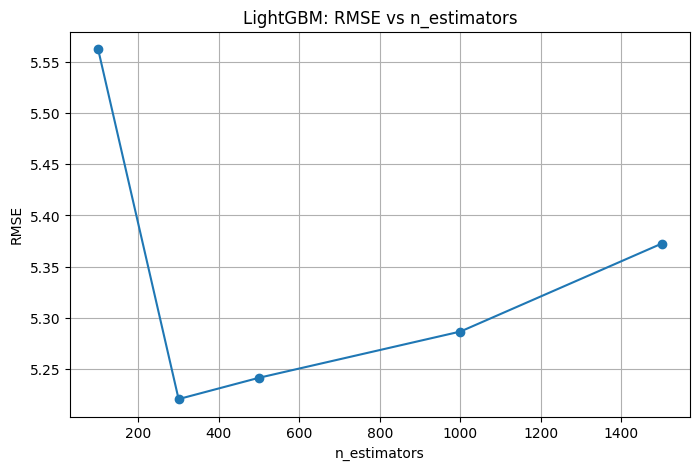

,rmse,mae,r2
n_estimators,,,
100,5.562430,2.607673,0.993610
300,5.220643,2.619839,0.994371
500,5.241481,2.680818,0.994326
1000,5.286599,2.782179,0.994228
1500,5.372477,2.859238,0.994039


In [19]:
n_estimators_list = [100, 300, 500, 1000, 1500]
results_n = []

for n in n_estimators_list:
    model = LGBMRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )
    r = run_and_record(model, f"LGBM_n_estimators_{n}", all_results)
    results_n.append(r)

# Build DataFrame for plotting
df_n = pd.DataFrame([{
    "n_estimators": r['model'].get_params()['n_estimators'],
    **r['metrics']
} for r in results_n])

plt.figure(figsize=(8,5))
plt.plot(df_n['n_estimators'], df_n['rmse'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('LightGBM: RMSE vs n_estimators')
plt.grid(True)
plt.savefig('lgbm_n_estimators_sweep.png')
plt.show()

# Show table
display(df_n.set_index('n_estimators'))

Running: LGBM_lr_0.01...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

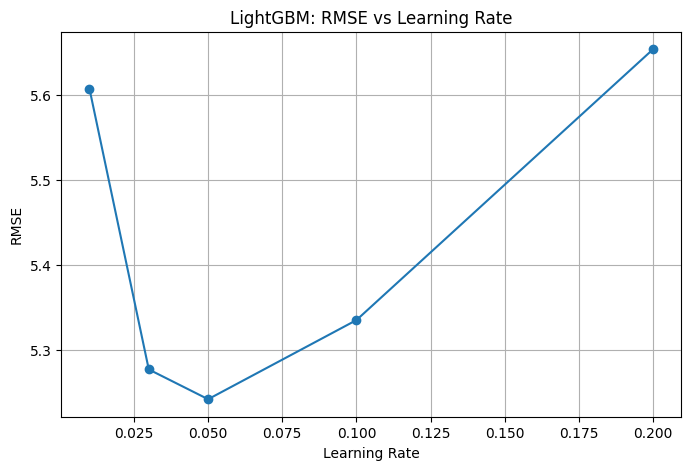

,rmse,mae,r2
learning_rate,,,
0.01,5.607446,2.644871,0.993506
0.03,5.276572,2.624366,0.994250
0.05,5.241481,2.680818,0.994326
0.10,5.334740,2.843382,0.994122
0.20,5.653972,3.134967,0.993398


In [20]:
learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.2]
results_lr = []

for lr in learning_rate_list:
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=lr,
        max_depth=10,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )
    r = run_and_record(model, f"LGBM_lr_{lr}", all_results)
    results_lr.append(r)

# Build DataFrame for plotting
df_lr = pd.DataFrame([{
    "learning_rate": r['model'].get_params()['learning_rate'],
    **r['metrics']
} for r in results_lr])

plt.figure(figsize=(8,5))
plt.plot(df_lr['learning_rate'], df_lr['rmse'], marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('LightGBM: RMSE vs Learning Rate')
plt.grid(True)
plt.savefig('lgbm_learning_rate_sweep.png')
plt.show()

# Show table
display(df_lr.set_index('learning_rate'))

Running: LGBM_depth_6_leaves_32...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

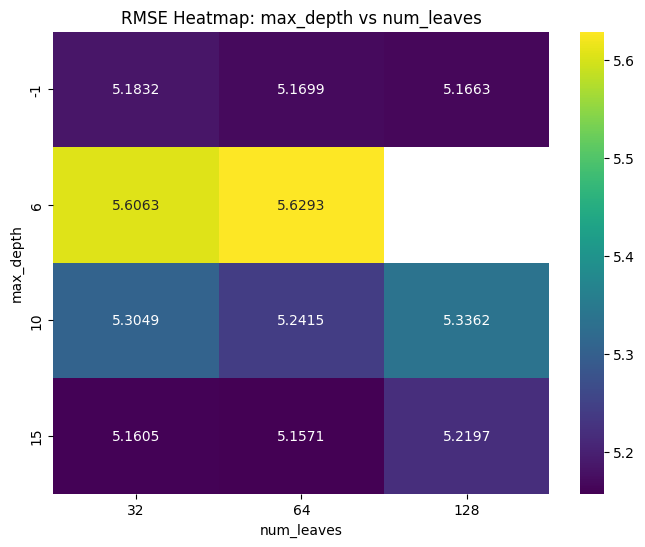

num_leaves,32,64,128
max_depth,,,
-1,5.183152,5.169901,5.166300
6,5.606255,5.629290,NaN
10,5.304892,5.241481,5.336210
15,5.160495,5.157128,5.219703


In [21]:
depth_list = [6, 10, 15, -1] # -1 = no limit
num_leaves_list = [32, 64, 128]
results_leaves = []

for d in depth_list:
    for nl in num_leaves_list:
        # num_leaves must be <= 2^max_depth (or it's redundant)
        if d != -1 and nl > (2**d):
            continue

        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=d,
            num_leaves=nl,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_depth_{d}_leaves_{nl}"
        r = run_and_record(model, name, all_results)
        results_leaves.append(r)

# Pivot table for RMSE
rows = []
for r in results_leaves:
    params = r['model'].get_params()
    rows.append({
        'max_depth': params['max_depth'],
        'num_leaves': params['num_leaves'],
        'rmse': r['metrics']['rmse']
    })

df_leaves = pd.DataFrame(rows)
pivot_leaves = df_leaves.pivot(index='max_depth', columns='num_leaves', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_leaves, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('num_leaves')
plt.ylabel('max_depth')
plt.title('RMSE Heatmap: max_depth vs num_leaves')
plt.savefig('lgbm_depth_leaves_heatmap.png')
plt.show()

display(pivot_leaves)

Running: LGBM_sub_0.7_col_0.7...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5123
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

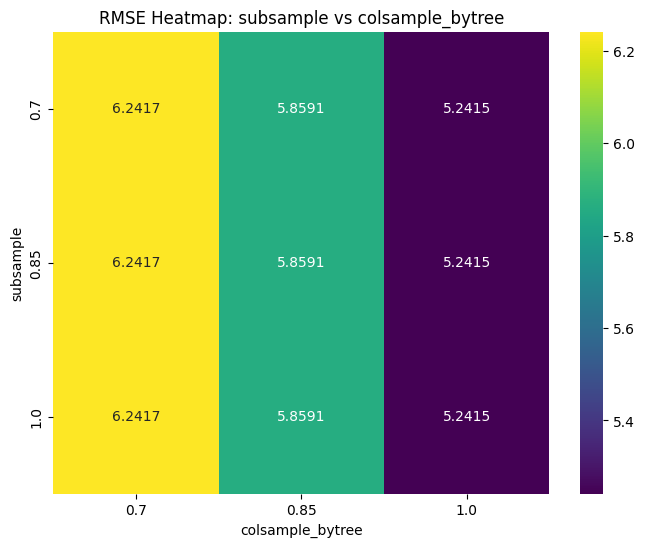

colsample_bytree,0.70,0.85,1.00
subsample,,,
0.70,6.24174,5.859092,5.241481
0.85,6.24174,5.859092,5.241481
1.00,6.24174,5.859092,5.241481


In [22]:
subsample_list = [0.7, 0.85, 1.0] # 1.0 = use all data
colsample_list = [0.7, 0.85, 1.0] # 1.0 = use all features
results_sub = []

for ss in subsample_list:
    for cs in colsample_list:
        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            num_leaves=64,
            subsample=ss,
            colsample_bytree=cs,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_sub_{ss}_col_{cs}"
        r = run_and_record(model, name, all_results)
        results_sub.append(r)

# Pivot table for RMSE
rows = []
for r in results_sub:
    params = r['model'].get_params()
    rows.append({
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'rmse': r['metrics']['rmse']
    })

df_sub = pd.DataFrame(rows)
pivot_sub = df_sub.pivot(index='subsample', columns='colsample_bytree', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('colsample_bytree')
plt.ylabel('subsample')
plt.title('RMSE Heatmap: subsample vs colsample_bytree')
plt.savefig('lgbm_subsample_heatmap.png')
plt.show()

display(pivot_sub)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

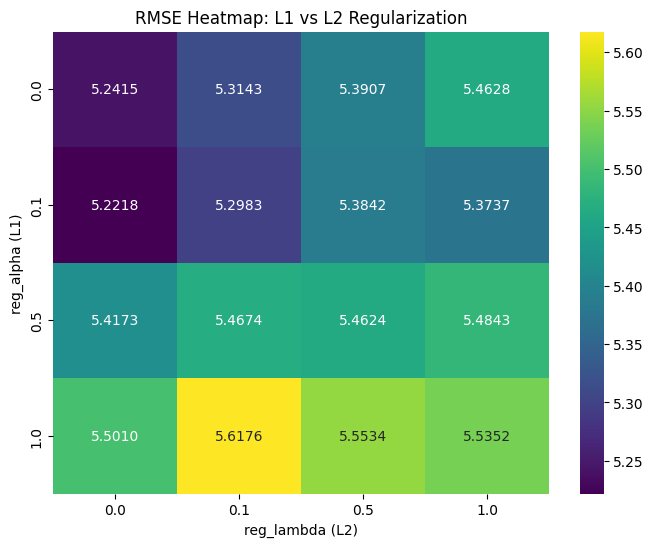

reg_lambda (L2),0.0,0.1,0.5,1.0
reg_alpha (L1),,,,
0.0,5.241481,5.314289,5.390746,5.462834
0.1,5.221844,5.298260,5.384209,5.373678
0.5,5.417277,5.467436,5.462450,5.484317
1.0,5.500968,5.617620,5.553370,5.535233


In [23]:
alpha_list = [0.0, 0.1, 0.5, 1.0]
lambda_list = [0.0, 0.1, 0.5, 1.0]
results_reg = []

for ra in alpha_list:
    for rl in lambda_list:
        model = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            num_leaves=64,
            reg_alpha=ra,
            reg_lambda=rl,
            random_state=42,
            n_jobs=-1
        )
        name = f"LGBM_alpha_{ra}_lambda_{rl}"
        r = run_and_record(model, name, all_results)
        results_reg.append(r)

# Pivot table for RMSE
rows = []
for r in results_reg:
    params = r['model'].get_params()
    rows.append({
        'reg_alpha (L1)': params['reg_alpha'],
        'reg_lambda (L2)': params['reg_lambda'],
        'rmse': r['metrics']['rmse']
    })

df_reg = pd.DataFrame(rows)
pivot_reg = df_reg.pivot(index='reg_alpha (L1)', columns='reg_lambda (L2)', values='rmse')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_reg, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('reg_lambda (L2)')
plt.ylabel('reg_alpha (L1)')
plt.title('RMSE Heatmap: L1 vs L2 Regularization')
plt.savefig('lgbm_regularization_heatmap.png')
plt.show()

display(pivot_reg)

In [24]:
summary_rows = []
for r in all_results:
    params = r['model'].get_params()
    summary_rows.append({
        'name': r['name'],
        'n_estimators': params.get('n_estimators'),
        'depth': params.get('max_depth'),
        'learning_rate': params.get('learning_rate'),
        'num_leaves': params.get('num_leaves'),
        'subsample': params.get('subsample'),
        'colsample_bytree': params.get('colsample_bytree'),
        'reg_alpha': params.get('reg_alpha'),
        'reg_lambda': params.get('reg_lambda'),
        'rmse': r['metrics']['rmse'],
        'mae': r['metrics']['mae'],
        'r2': r['metrics']['r2'],
        'train_time_s': r['train_time']
    })

df_summary = pd.DataFrame(summary_rows).sort_values('rmse')

# Show top 10 best runs
print("Top 10 performing LightGBM models by RMSE:")
display(df_summary.head(10))

# Save summary to CSV
try:
    df_summary.to_csv('lightgbm_parameter_sweep_summary.csv', index=False)
    print('\nSaved summary to lightgbm_parameter_sweep_summary.csv')
except Exception as e:
    print(f'Could not save summary CSV: {e}')

Top 10 performing LightGBM models by RMSE:


,name,n_estimators,depth,learning_rate,num_leaves,subsample,colsample_bytree,reg_alpha,reg_lambda,rmse,mae,r2,train_time_s
18,LGBM_depth_15_leaves_64,500,15,0.05,64,1.0,1.0,0.0,0.0,5.157128,2.689301,0.994507,1.035959
64,LGBM_depth_15_leaves_64,500,15,0.05,64,1.0,1.0,0.0,0.0,5.157128,2.689301,0.994507,5.114397
63,LGBM_depth_15_leaves_32,500,15,0.05,32,1.0,1.0,0.0,0.0,5.160495,2.648213,0.994500,2.674746
17,LGBM_depth_15_leaves_32,500,15,0.05,32,1.0,1.0,0.0,0.0,5.160495,2.648213,0.994500,0.786112
68,LGBM_depth_-1_leaves_128,500,-1,0.05,128,1.0,1.0,0.0,0.0,5.166300,2.633380,0.994487,3.067440
22,LGBM_depth_-1_leaves_128,500,-1,0.05,128,1.0,1.0,0.0,0.0,5.166300,2.633380,0.994487,3.950240
21,LGBM_depth_-1_leaves_64,500,-1,0.05,64,1.0,1.0,0.0,0.0,5.169901,2.656721,0.994480,1.603788
67,LGBM_depth_-1_leaves_64,500,-1,0.05,64,1.0,1.0,0.0,0.0,5.169901,2.656721,0.994480,1.575028
66,LGBM_depth_-1_leaves_32,500,-1,0.05,32,1.0,1.0,0.0,0.0,5.183152,2.673516,0.994451,0.856412
20,LGBM_depth_-1_leaves_32,500,-1,0.05,32,1.0,1.0,0.0,0.0,5.183152,2.673516,0.994451,0.855749



Saved summary to lightgbm_parameter_sweep_summary.csv
